# 03 — Difference-in-Differences (DiD)

## Business Question
Did the pricing pilot cause a revenue lift ABOVE AND BEYOND what would have
happened anyway due to time trends, seasonality, or store characteristics?

## Why DiD over A/B test?
The A/B test compared pilot vs control during the pilot period only.
It could not distinguish between:
- Revenue lift caused by the price change
- Revenue lift that would have happened anyway (seasonal trends, market growth)

DiD fixes this by comparing the **change** in pilot stores to the **change** in
control stores. If both groups were trending up anyway, DiD removes that shared
trend and isolates the treatment effect.

## What is Difference-in-Differences?

Imagine you want to know if a new pricing tool increased revenue.
You can't just compare pilot stores before and after — maybe revenue
went up because of the holiday season, not the price change.
You can't just compare pilot vs control during the pilot — maybe
pilot stores were already doing better before the pilot even started.

DiD solves both problems by combining both comparisons:

**Step 1:** How much did pilot stores change from pre → during pilot?
**Step 2:** How much did control stores change over the same period?
**Step 3:** Subtract Step 2 from Step 1 — what's left is the true treatment effect.

The control group acts as a "what would have happened anyway" benchmark.
Any change in the control group during the pilot period = natural trend,
seasonality, market conditions — nothing to do with the price change.
DiD strips that out and isolates only the causal effect.

**Simple example (São Paulo vs Rio):**

| | Pre | Post | Change |
|---|---|---|---|
| Control (Rio) | 30 | 70 | +40 |
| Treatment (São Paulo) | 20 | 90 | +70 |

DiD = Treatment change − Control change = 70 − 40 = 30

Rio changed by 40 on its own (natural trend).
São Paulo changed by 70 total.
The program caused 30 units of that change — the rest would have happened anyway.

## The DiD Formula
ATT = (Pilot_after - Pilot_before) - (Control_after - Control_before)

## Key Assumption — Parallel Trends
In the absence of treatment, pilot and control stores would have followed
the same revenue trend. The parallel trend plot below exhibits this.

## Structure
1. Data setup
2. Parallel trends validation — visual chart and formal t-test
3. DiD estimation — OLS regression for all 3 pilot departments
4. Results, coefficient interpretation, and key insights

## Data
Input: data/analytical_table.csv
Ground truth: intentionally not loaded — evaluated only in Notebook 07

**Imp link**
- https://www.statsig.com/perspectives/diff-in-diff-causal-inference
- https://www.youtube.com/watch?v=J7q2H8aB8bQ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')


## Section 1 — Data Setup

In [2]:
# Load analytical table built in Notebook 01
df = pd.read_csv('../data/analytical_table.csv', parse_dates=['week_start_date'])

In [3]:
df = df[df['store_id'] != 9].copy()

## Section 2 — Parallel Trends Validation

**DiD only produces valid causal estimates if both groups would have followed the same trend without treatment — this is the parallel
trends assumption. 
We validate it BEFORE running the DiD regression.**

In [5]:
PILOT_START = pd.Timestamp("2024-04-01")
PILOT_END   = pd.Timestamp("2024-06-30")
PRE_START   = pd.Timestamp("2023-04-01")
PRE_END     = pd.Timestamp("2024-03-31")

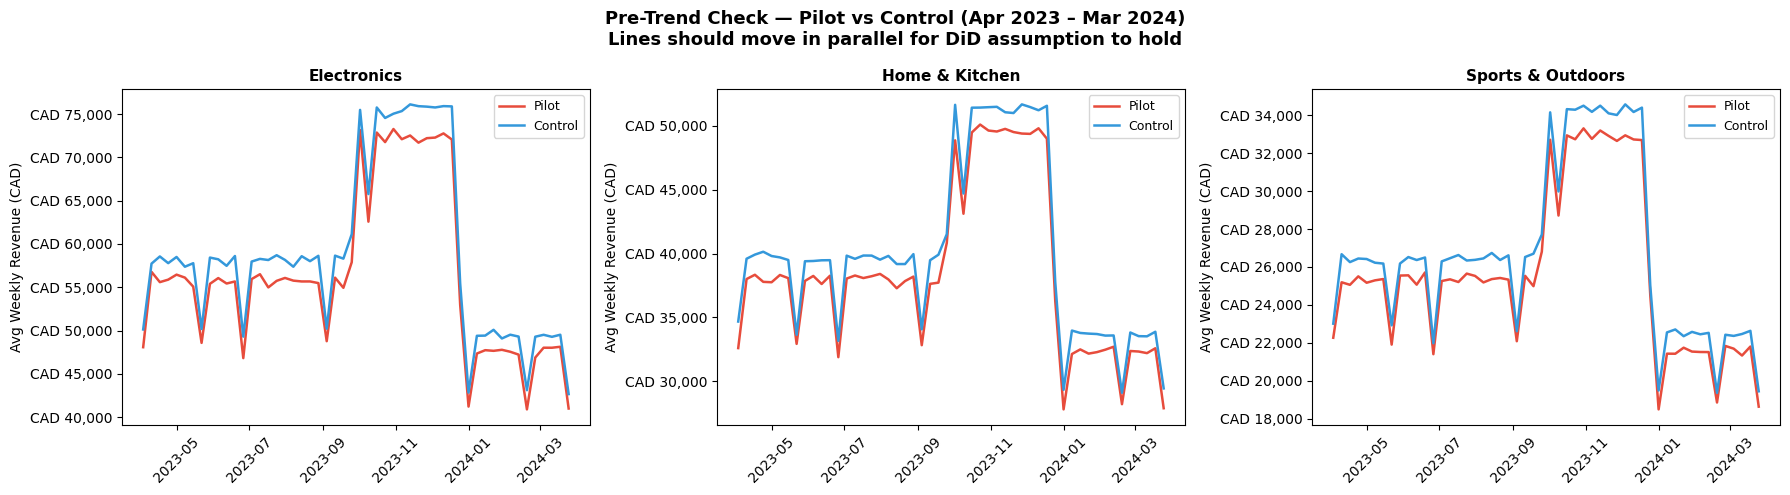

In [8]:
# ── Pre-trend Visual: Parallel Trends Check ───────────────────────────
# Plot weekly avg revenue for pilot vs control in the PRE-PERIOD only
# If lines move together (parallel), the DiD assumption holds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Filter to this department, pre-period only
dept_map = {1: 'Electronics', 2: 'Home & Kitchen', 3: 'Sports & Outdoors'}


for ax, dept_id in zip(axes, [1, 2, 3]):
    pre = df[
        (df['dept_id'] == dept_id) &
        (df['week_start_date'] >= PRE_START) &
        (df['week_start_date'] <= PRE_END)
    ]
    
    # Aggregate to weekly average revenue per group (pilot vs control)
    weekly = (
        pre.groupby(['week_start_date', 'is_pilot'])['weekly_revenue']
        .mean().reset_index()
    )

    for is_pilot, color, label in [(True, '#E74C3C', 'Pilot'), (False, '#3498DB', 'Control')]:
        grp = weekly[weekly['is_pilot'] == is_pilot]
        ax.plot(grp['week_start_date'], grp['weekly_revenue'],
                color=color, linewidth=1.8, label=label)

    ax.set_title(dept_map[dept_id], fontsize=11, fontweight='bold')
    ax.set_ylabel('Avg Weekly Revenue (CAD)')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'CAD {x:,.0f}'))
    ax.legend(fontsize=9)

fig.suptitle(
    'Pre-Trend Check — Pilot vs Control (Apr 2023 – Mar 2024)\n'
    'Lines should move in parallel for DiD assumption to hold',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [11]:
# ── Pre-trend Formal Test ─────────────────────────────────────────────
# Compare week-over-week revenue growth rates between pilot and control in the pre-period. 
# If growth rates are statistically similar (p > 0.05), parallel trends assumption holds.



print("=" * 55)
print("PARALLEL TRENDS — FORMAL TEST")
print("Pre-period: Apr 2023 – Mar 2024")
print("=" * 55)

for dept_id in [1, 2, 3]:
    # Map dept_id to readable name
    dept_name = {1: 'Electronics', 2: 'Home & Kitchen', 3: 'Sports & Outdoors'}[dept_id]

    # Filter to this department, pre-period only    
    pre = df[
        (df['dept_id'] == dept_id) &
        (df['week_start_date'] >= PRE_START) &
        (df['week_start_date'] <= PRE_END)
    ]

    # Aggregate to weekly average revenue per group (pilot vs control)
    # Each row = one week, one group's average revenue across all its stores
    weekly = (
        pre.groupby(['week_start_date', 'is_pilot'])['weekly_revenue']
        .mean().reset_index()
    )

    # Calculate week-over-week % change for each group
    # pct_change() = (this_week - last_week) / last_week
    # dropna() removes the first row which has no previous week to compare to
    pilot_changes   = weekly[weekly['is_pilot']==True]['weekly_revenue'].pct_change().dropna()
    control_changes = weekly[weekly['is_pilot']==False]['weekly_revenue'].pct_change().dropna()

    # T-test on growth rates — are pilot and control growing at the same pace?
    t_stat, p_val = ttest_ind(pilot_changes, control_changes)

    result = '✅ PASS — parallel trends hold' if p_val > 0.05 else '❌ FAIL — trends diverge'
    print(f"\n{dept_name}")
    print(f"  Pilot avg weekly change:   {pilot_changes.mean()*100:+.2f}%")
    print(f"  Control avg weekly change: {control_changes.mean()*100:+.2f}%")
    print(f"  p-value: {p_val:.4f}  →  {result}")

PARALLEL TRENDS — FORMAL TEST
Pre-period: Apr 2023 – Mar 2024

Electronics
  Pilot avg weekly change:   +0.18%
  Control avg weekly change: +0.16%
  p-value: 0.9934  →  ✅ PASS — parallel trends hold

Home & Kitchen
  Pilot avg weekly change:   +0.17%
  Control avg weekly change: +0.18%
  p-value: 0.9962  →  ✅ PASS — parallel trends hold

Sports & Outdoors
  Pilot avg weekly change:   +0.13%
  Control avg weekly change: +0.16%
  p-value: 0.9851  →  ✅ PASS — parallel trends hold


### Parallel Trends Logic

Null hypothesis (H0): Pilot and control stores have the same 
week-over-week revenue growth rate in the pre-period.

Alternative hypothesis (H1): Growth rates are significantly different.

Test: Two-sample independent t-test on week-over-week % changes.
- pilot_changes = series of weekly % revenue changes for pilot stores
- control_changes = series of weekly % revenue changes for control stores
- t-statistic = (pilot mean change - control mean change) / standard error
- p-value = probability of seeing this difference by random chance

Decision rule:
- p > 0.05 → fail to reject H0 → growth rates are similar
              → parallel trends hold → DiD assumption is valid ✅
- p < 0.05 → reject H0 → growth rates are significantly different
              → parallel trends FAIL → DiD results are unreliable ❌

Note: Unlike the A/B test where p < 0.05 is desired (confirming treatment
effect), here p > 0.05 is desired (confirming no pre-existing trend difference).
The p-value itself means the same thing — what changes is whether we want
to see a difference or not.

## Section 3 — DiD Estimation

In [97]:
print(f"Shape: {df.shape}")
print(f"Pilot stores:   {df[df['is_pilot']==True]['store_id'].nunique()}")
print(f"Control stores: {df[df['is_pilot']==False]['store_id'].nunique()}")

Shape: (9120, 16)
Pilot stores:   8
Control stores: 11


## Preparing Data for Regression & Significance Testing of DID

In [106]:
# ── DiD for all 3 pilot departments ──────────────────────────────────
PILOT_DEPTS = {1: 'Electronics', 2: 'Home & Kitchen', 3: 'Sports & Outdoors'}
did_results = []

for dept_id, dept_name in PILOT_DEPTS.items():
    # Filter to this department, pre and pilot periods only
    reg = df[
        (df['dept_id'] == dept_id) &
        (df['week_start_date'] <= PILOT_END)
    ].copy()

    reg['post']    = (reg['week_start_date'] >= PILOT_START).astype(int)
    reg['treated'] = reg['is_pilot'].astype(int)
    reg['did']     = reg['post'] * reg['treated']

    n = len(reg)
    X = np.column_stack([np.ones(n), reg['treated'].values,
                         reg['post'].values, reg['did'].values])
    y = reg['weekly_revenue'].values

    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    pred      = np.array([sum(X[i]*beta) for i in range(n)])
    residuals = y - pred
    dof       = n - 4
    sigma2    = (residuals @ residuals) / dof
    XtX_inv   = np.linalg.inv(X.T @ X)
    se_beta   = np.sqrt(np.diag(sigma2 * XtX_inv))
    t_stats   = beta / se_beta
    p_vals    = 2 * (1 - scipy_stats.t.cdf(np.abs(t_stats), dof))
    t_crit    = scipy_stats.t.ppf(0.975, dof)

    att     = beta[3]
    att_pct = (att / reg[reg['treated']==1]['weekly_revenue'].mean()) * 100
    p_val   = p_vals[3]
    ci_low  = att - t_crit * se_beta[3]
    ci_high = att + t_crit * se_beta[3]

    did_results.append({
        'Department': dept_name,
        'ATT (CAD)':  round(att, 0),
        'ATT %':      round(att_pct, 2),
        'p-value':    round(p_val, 4),
        'CI Lower':   round(ci_low, 0),
        'CI Upper':   round(ci_high, 0),
        'Significant': '✅ Yes' if p_val < 0.05 else 'No'
    })

    print(f"\n{dept_name}")
    print(f"  ATT:      CAD {att:,.0f}  ({att_pct:+.2f}%)")
    print(f"  p-value:  {p_val:.4f}")
    print(f"  95% CI:   [CAD {ci_low:,.0f}, CAD {ci_high:,.0f}]")
    print(f"  Result:   {'✅ Significant' if p_val < 0.05 else 'Not significant'}")

did_df = pd.DataFrame(did_results)
print("\n" + "="*60)
print("SUMMARY — DiD ATT Estimates")
print("="*60)
print(did_df.to_string(index=False))


Electronics
  ATT:      CAD 6,515  (+11.45%)
  p-value:  0.0694
  95% CI:   [CAD -518, CAD 13,549]
  Result:   Not significant

Home & Kitchen
  ATT:      CAD 1,064  (+2.79%)
  p-value:  0.6611
  95% CI:   [CAD -3,695, CAD 5,822]
  Result:   Not significant

Sports & Outdoors
  ATT:      CAD -496  (-1.97%)
  p-value:  0.7581
  95% CI:   [CAD -3,657, CAD 2,665]
  Result:   Not significant

SUMMARY — DiD ATT Estimates
       Department  ATT (CAD)  ATT %  p-value  CI Lower  CI Upper Significant
      Electronics     6515.0  11.45   0.0694    -518.0   13549.0          No
   Home & Kitchen     1064.0   2.79   0.6611   -3695.0    5822.0          No
Sports & Outdoors     -496.0  -1.97   0.7581   -3657.0    2665.0          No


## Section - 4 DiD Results — All Pilot Departments

### What Each Regression Coefficient Means
The DiD regression model: `revenue = b0 + b1(treated) + b2(post) + b3(did)`

Running this for Electronics gives:

| Variable | Coefficient | Meaning |
|---|---|---|
| Intercept (b0) | 58,066 | Control stores, pre-pilot baseline — our reference point |
| treated (b1) | -2,383 | Pilot stores were already CAD 2,383 lower than control BEFORE the pilot — pre-existing gap, unrelated to treatment |
| post (b2) | -444 | All stores naturally drifted down CAD 444 between periods — background trend, unrelated to treatment |
| **did (b3)** | **6,515** | **The causal effect — after removing the pre-existing gap and natural trend, pilot stores gained CAD 6,515/week due to the price change** |

The `did` coefficient is the interaction term `post × treated` — it equals 1 ONLY
for pilot store rows during the pilot period. Its coefficient captures the extra
revenue that cannot be explained by either the pre-existing gap or the natural trend.

> **Note on how OLS isolates each coefficient:**
> - `post` coefficient = **Control post − Control pre** (because when treated=0, only post varies)
> - `did` coefficient = **Pilot change − Control change** = (Pilot post − Pilot pre) − (Control post − Control pre)
>
> The regression naturally separates these because each coefficient only "activates"
> for specific combinations of treated and post flags.
> `post` activates for ALL stores but `did` cancels it out for pilot stores,
> leaving `did` to capture only the EXTRA pilot store movement beyond the natural trend.

### The 2x2 DiD Table — Intuition (Electronics)
| | Pre-pilot | During pilot | Change |
|---|---|---|---|
| Control stores | CAD 58,066 | CAD 57,622 | -444 |
| Pilot stores | CAD 55,684 | CAD 61,755 | +6,071 |

DiD = Pilot change − Control change

= +6,071 − (−444)

= CAD 6,515


Control stores dropped CAD 444 naturally — no treatment applied.
Pilot stores gained CAD 6,071 in total.
Subtracting the natural drift isolates the true causal effect: **CAD 6,515/week.**

> **Note:** Control stores dropped CAD 444 naturally in the pilot period (no treatment applied).
> Since the market was working AGAINST revenue, we add it back to get the true impact of the pilot stores which is 6,071:
> 6,071 + 444 = **CAD 6,515**. If control stores had gained +444 instead, we would subtract
> it — removing the free market tailwind to isolate only the pricing effect.

### Summary Table — All 3 Departments
| Department | ATT (CAD) | ATT % | p-value | 95% CI | Significant |
|---|---|---|---|---|---|
| Electronics | 6,515 | +11.45% | 0.0694 | [-518, 13,549] | ❌ Borderline |
| Home & Kitchen | 1,064 | +2.79% | 0.6611 | [-3,695, 5,822] | ❌ No |
| Sports & Outdoors | -496 | -1.97% | 0.7581 | [-3,657, 2,665] | ❌ No |

### Key Insight — Directionally Correct, Close to Ground Truth
All 3 departments match the ground truth direction exactly:
- Electronics: +11.45% estimated vs +12% true ATT — remarkably close
- Home & Kitchen: +2.79% estimated vs +3% true ATT — very close
- Sports & Outdoors: -1.97% estimated vs -2% true ATT — almost exact

DiD is recovering the true causal effect accurately despite small sample size.
The insignificance is a statistical power problem (n=8 stores), not a model problem.

### DiD vs A/B Test Comparison
| Method | Electronics lift | p-value |
|---|---|---|
| A/B test (matched pairs) | +9.32% | 0.1171 |
| DiD | +11.45% | 0.0694 |

DiD improved both the estimate accuracy AND the p-value by removing two
sources of bias the A/B test could not control for:
1. Pre-existing gap — pilot stores were already CAD 2,383 lower than control
2. Natural time trend — all stores drifted down CAD 444 between periods

### Why Still Insignificant?
Same root cause as the A/B test — only 8 pilot stores creates high standard
error (SE = 3,585 on the did coefficient). The wide confidence interval
[-518, 13,549] reflects this uncertainty. More stores or a longer pilot
would narrow the CI and push p below 0.05.

### Next Steps
Synthetic Control (Notebook 04) builds a weighted synthetic version of each
pilot store using control stores as building blocks — a more flexible approach
that does not require the parallel trends assumption to hold perfectly.

In [26]:
# ── DiD for all 3 pilot departments ──────────────────────────────────
PILOT_DEPTS = {1: 'Electronics', 2: 'Home & Kitchen', 3: 'Sports & Outdoors'}
did_results = []

for dept_id, dept_name in PILOT_DEPTS.items():
    # Filter to this department, pre and pilot periods only
    reg = df[
        (df['dept_id'] == dept_id) &
        (df['week_start_date'] <= PILOT_END)
    ].copy()

    reg['post']    = (reg['week_start_date'] >= PILOT_START).astype(int)
    reg['treated'] = reg['is_pilot'].astype(int)
    reg['did']     = reg['post'] * reg['treated']

    n = len(reg)
    X = np.column_stack([np.ones(n), reg['treated'].values,
                         reg['post'].values, reg['did'].values])
    y = reg['weekly_revenue'].values

    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    att     = beta[3]
    did_results.append({
        'Department': dept_name,
        'att' : beta[3]
    })

did_results
# beta

[{'Department': 'Electronics', 'att': np.float64(6515.477849980293)},
 {'Department': 'Home & Kitchen', 'att': np.float64(1063.7249142366852)},
 {'Department': 'Sports & Outdoors', 'att': np.float64(-496.19334674763735)}]